In [1]:
%%time
# Imports principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from skimage.io import imread
from skimage.transform import resize
from collections import Counter

# Modelos y métricas
from sklearn.model_selection import train_test_split, learning_curve, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, label_binarize
# --- CORRECCIÓN: Importar LabelEncoder ---
from sklearn.preprocessing import LabelEncoder 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.pipeline import Pipeline

# --- IMPORT EXPERIMENTAL PARA HYPERBAND/HALVING ---
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV

# --- CLASIFICADORES ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

# Para distribuciones de Random Search
from scipy.stats import randint, uniform

CPU times: user 3.63 s, sys: 304 ms, total: 3.93 s
Wall time: 3.03 s


In [2]:
# Celda 1: Función para cargar imágenes (Sin cambios)
def load_image_dataset(root_dir, size=(64,64), max_per_class=None):
    X, y = [], []
    classes = sorted(os.listdir(root_dir))
    for cls in classes:
        cls_path = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_path):
            continue
        files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png','.jpg'))]
        if max_per_class:
            files = files[:max_per_class]
        for f in files:
            img = imread(os.path.join(cls_path, f))
            if img.ndim == 3:  # convertir a escala de grises si es RGB
                img = img[...,0]
            img_resized = resize(img, size, anti_aliasing=True)
            X.append(img_resized)
            y.append(cls)
    return np.array(X), np.array(y), classes

In [3]:
# Celda 2: Carga, normalización y división de datos (CORREGIDA)
X, y_str, classes = load_image_dataset("CMS_data", size=(64,64))
print("Datos cargados.")
print(f"Clases (strings): {classes}")

# --- CORRECCIÓN: Convertir etiquetas de string a enteros ---
le = LabelEncoder()
y_int = le.fit_transform(y_str)
# classes sigue siendo nuestra lista de nombres: ['electron', 'muon', ...]
# y_int ahora es [0, 0, 1, 3, 4, 5, 2, ...]
print(f"Etiquetas convertidas a enteros (ej: {y_int[0:5]})")

# Normalizar y Aplanar X (Sin cambios)
X = X / X.max()
X_flat = X.reshape(len(X), -1)

# División train/test (Usando y_int)
X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y_int, test_size=0.2, stratify=y_int, random_state=42
)

# y_test ahora contiene enteros (0, 1, 2...)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Datos cargados.
Clases (strings): ['electron', 'muon', 'neutrino', 'proton', 'quark', 'tau']
Etiquetas convertidas a enteros (ej: [0 0 0 0 0])
Train: (48000, 4096), Test: (12000, 4096)


In [4]:
# Binarizar las etiquetas (necesario para ROC multiclase)
# --- CORRECCIÓN: Binarizamos sobre los enteros 0, 1, 2... ---
y_test_bin = label_binarize(y_test, classes=np.arange(len(classes)))
n_classes = y_test_bin.shape[1]
print(f"Número de clases binarizadas: {n_classes}")

Número de clases binarizadas: 6


In [5]:
# --- Función para graficar ROC ---
def plot_multiclass_roc(y_test_bin, y_score, classes, title):
    plt.figure(figsize=(8,6))
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{classes[i]} (AUC = {roc_auc:.2f})")
    plt.plot([0,1], [0,1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

# --- Función para graficar Curvas de Aprendizaje ---
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=3, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)):
    plt.figure(figsize=(10, 6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Ejemplos de entrenamiento")
    plt.ylabel("Score (Accuracy)")
    
    train_sizes_abs, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring="accuracy"
    )
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    plt.grid(True)
    
    plt.fill_between(train_sizes_abs, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes_abs, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    
    plt.plot(train_sizes_abs, train_scores_mean, 'o-', color="r",
             label="Score de Entrenamiento (Train)")
    plt.plot(train_sizes_abs, test_scores_mean, 'o-', color="g",
             label="Score de Validación (Test/CV)")
    
    plt.legend(loc="best")
    plt.show()

In [12]:
%%time
print("Iniciando HalvingRandomSearch para ANN (MLPClassifier)...")

# Usamos el Pipeline con StandardScaler
pipeline_ann = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(random_state=42, max_iter=1000, early_stopping=True, n_iter_no_change=10))
])

# Parámetros para el MLP (Red Neuronal)
param_dist_ann = {
    'mlp__hidden_layer_sizes': [(50,), (100,), (150,), (50, 25), (100, 50)], 
    'mlp__alpha': uniform(0.0001, 0.01),
    'mlp__activation': ['relu', 'tanh']
}

halving_ann = HalvingRandomSearchCV(
    pipeline_ann, 
    param_distributions=param_dist_ann, 
    factor=3,
    cv=3, 
    scoring='accuracy', 
    n_jobs=-1, 
    random_state=42, 
    verbose=1
)
# ¡Esto ahora funcionará!
halving_ann.fit(X_train, y_train)

# Obtenemos el mejor pipeline
best_ann = halving_ann.best_estimator_
print(f"Mejores parámetros para ANN: {halving_ann.best_params_}")

Iniciando HalvingRandomSearch para ANN (MLPClassifier)...
n_iterations: 7
n_required_iterations: 7
n_possible_iterations: 7
min_resources_: 36
max_resources_: 48000
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 1333
n_resources: 36
Fitting 3 folds for each of 1333 candidates, totalling 3999 fits
----------
iter: 1
n_candidates: 445
n_resources: 108
Fitting 3 folds for each of 445 candidates, totalling 1335 fits
----------
iter: 2
n_candidates: 149
n_resources: 324
Fitting 3 folds for each of 149 candidates, totalling 447 fits
----------
iter: 3
n_candidates: 50
n_resources: 972
Fitting 3 folds for each of 50 candidates, totalling 150 fits
----------
iter: 4
n_candidates: 17
n_resources: 2916
Fitting 3 folds for each of 17 candidates, totalling 51 fits
----------
iter: 5
n_candidates: 6
n_resources: 8748
Fitting 3 folds for each of 6 candidates, totalling 18 fits
----------
iter: 6
n_candidates: 2
n_resources: 26244
Fitting 3 folds for each of 2 candidates, to

In [13]:
print("--- Reporte de Clasificación (ANN) ---")
y_pred_ann = best_ann.predict(X_test)
print(classification_report(y_test, y_pred_ann, target_names=classes))

--- Reporte de Clasificación (ANN) ---
              precision    recall  f1-score   support

    electron       0.46      0.46      0.46      2000
        muon       0.48      0.42      0.45      2000
    neutrino       0.79      0.78      0.79      2000
      proton       1.00      1.00      1.00      2000
       quark       0.99      0.98      0.99      2000
         tau       0.67      0.78      0.72      2000

    accuracy                           0.74     12000
   macro avg       0.73      0.74      0.73     12000
weighted avg       0.73      0.74      0.73     12000



--- Matriz de Confusión (ANN) ---


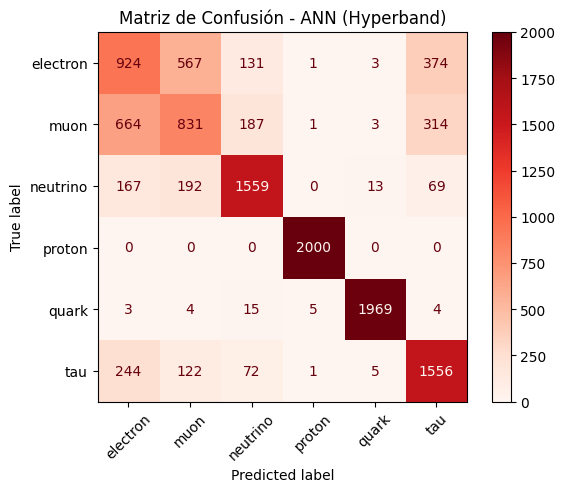

In [14]:
print("--- Matriz de Confusión (ANN) ---")
cm_ann = confusion_matrix(y_test, y_pred_ann)
disp_ann = ConfusionMatrixDisplay(confusion_matrix=cm_ann, display_labels=classes)
disp_ann.plot(cmap="Reds", xticks_rotation=45)
plt.title("Matriz de Confusión - ANN (Hyperband)")
plt.show()

--- Precisión por Clase (ANN) ---


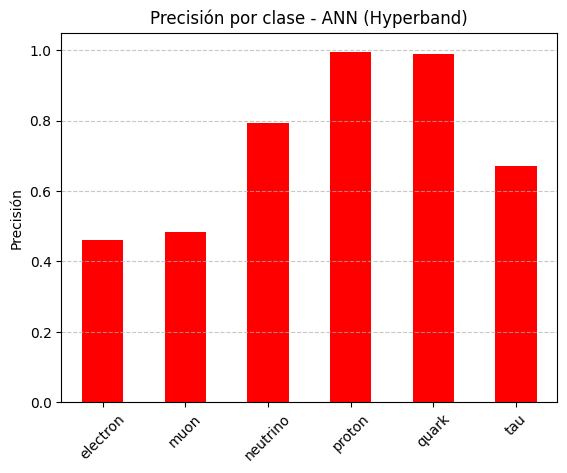

In [15]:
print("--- Precisión por Clase (ANN) ---")
report_ann_dict = classification_report(y_test, y_pred_ann, output_dict=True, target_names=classes)
df_ann = pd.DataFrame(report_ann_dict).transpose()
df_ann.loc[classes, "precision"].plot(kind="bar", color="red")
plt.title("Precisión por clase - ANN (Hyperband)")
plt.ylabel("Precisión")
plt.ylim(0, 1.05); plt.xticks(rotation=45); plt.grid(axis='y', linestyle='--', alpha=0.7); plt.show()

--- Curvas ROC (ANN) ---


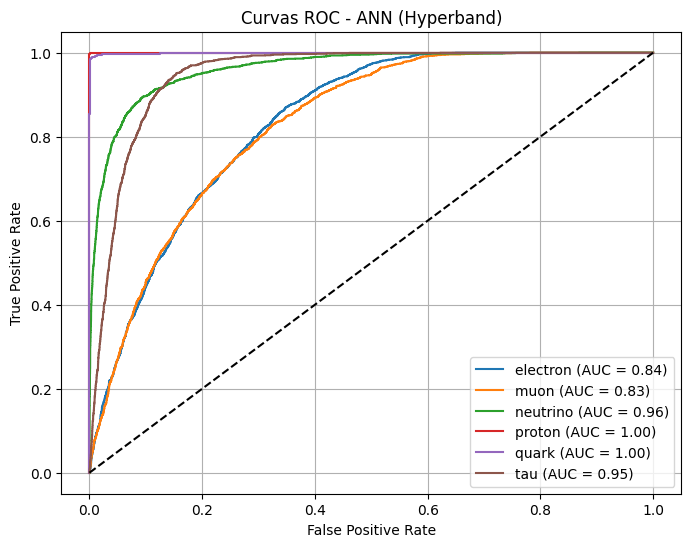

In [16]:
print("--- Curvas ROC (ANN) ---")
y_score_ann = best_ann.predict_proba(X_test)
plot_multiclass_roc(y_test_bin, y_score_ann, classes, "Curvas ROC - ANN (Hyperband)")

--- Curva de Aprendizaje (ANN) ---


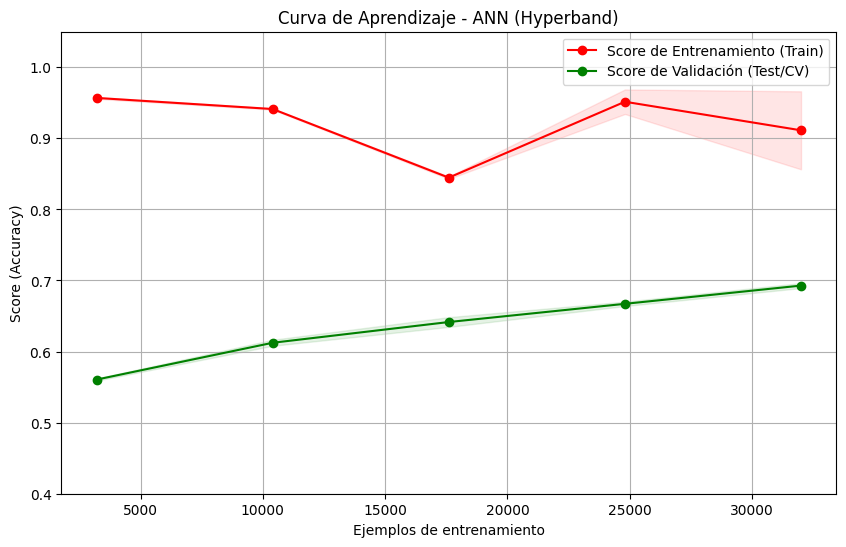

In [17]:
print("--- Curva de Aprendizaje (ANN) ---")
plot_learning_curve(best_ann, "Curva de Aprendizaje - ANN (Hyperband)", X_train, y_train, cv=3, ylim=(0.4, 1.05))